# Customer Sales Analysis

This project analyzes customer purchasing behavior using Python and Pandas.
The goal is to identify top customers, analyze product performance, and
discover sales trends that can help businesses make data-driven decisions.

## Step 1: Import Required Libraries

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Datasets

In [50]:
sales = pd.read_csv("sales_data.csv")
customers = pd.read_csv("customer_churn.csv")

sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


## Step 3: Data Exploration

In [51]:
sales.info()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   P

In [52]:
sales.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


## Step 4: Check Dataset Columns

In [53]:
sales.columns
customers.columns

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

The column names were inspected to determine how the datasets
could be merged using customer identifiers.

## Step 5: Merge Sales and Customer Data

In [54]:
data = pd.merge(sales, customers, left_on="Customer_ID", right_on="CustomerID")

data.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn


## Step 6: Total Revenue Analysis

In [55]:
total_revenue = sales["Total_Sales"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 12365048


## Step 7: Top Customers by Revenue

In [56]:
top_customers = sales.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False).head(10)

top_customers

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64

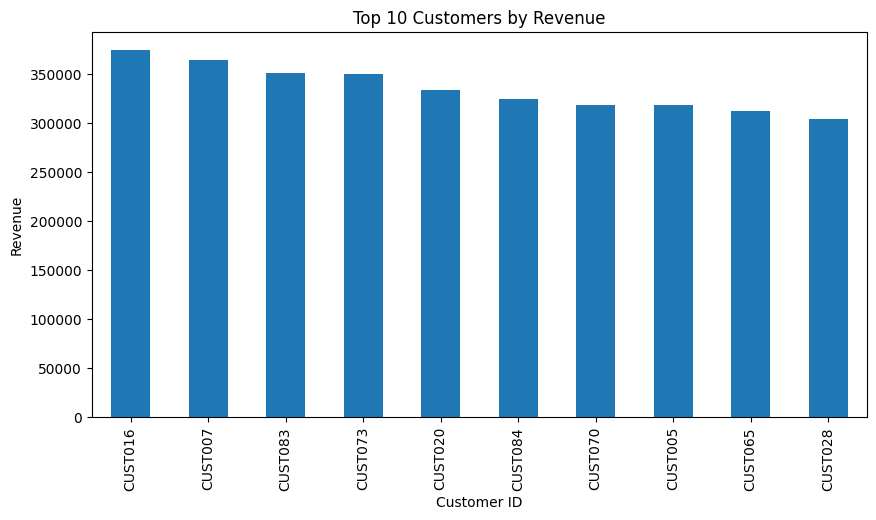

In [57]:
top_customers.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.show()

## Step 8: Monthly Sales Trend

In [58]:
sales["Date"] = pd.to_datetime(sales["Date"])

sales["Month"] = sales["Date"].dt.month

monthly_sales = sales.groupby("Month")["Total_Sales"].sum()

monthly_sales

Month
1    4120524
2    2656050
3    4485006
4    1103468
Name: Total_Sales, dtype: int64

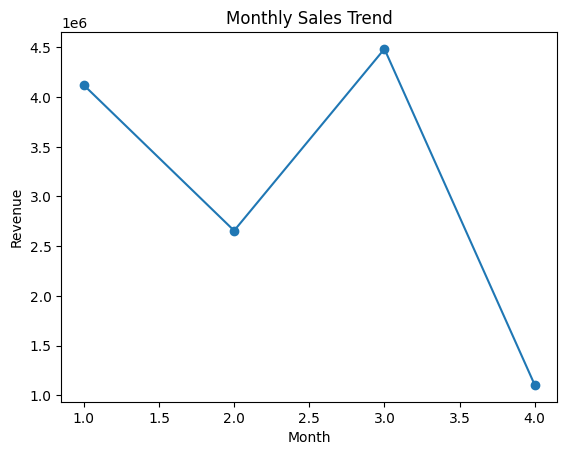

In [59]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Step 9: Product Sales Analysis

In [60]:
product_sales = sales.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

product_sales

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

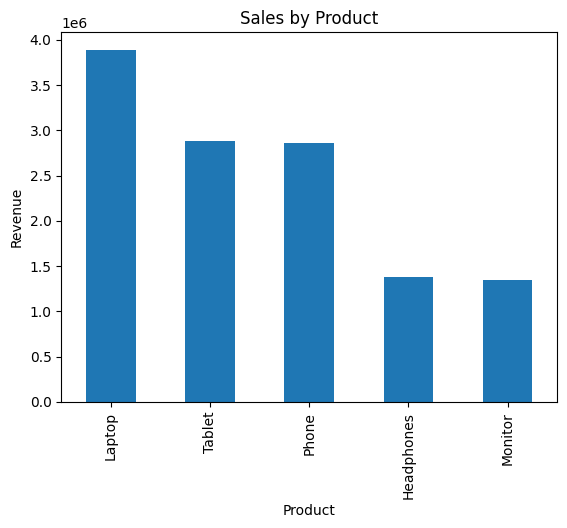

In [61]:
product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

## Step 10: Pivot Table Analysis

In [62]:
pivot = pd.pivot_table(
    sales,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum"
)

pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


## Step 11: Heatmap Visualization

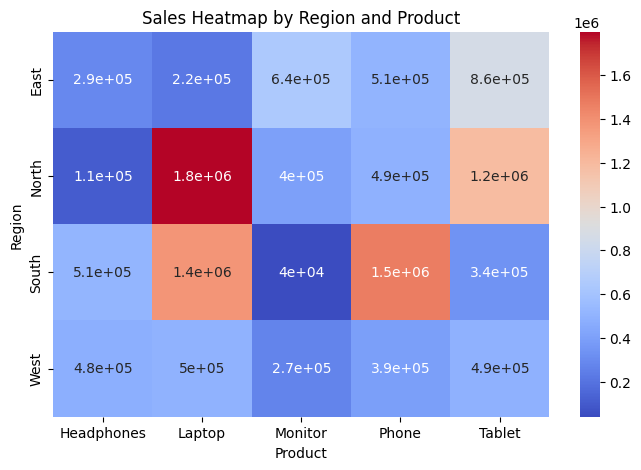

In [63]:
plt.figure(figsize=(8,5))

sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Sales Heatmap by Region and Product")

plt.show()

## Step 12: Key Business Insights

1. A small number of customers contribute significantly to revenue.
2. Monthly sales trends indicate seasonal demand patterns.
3. Some products generate higher revenue than others.
4. Regional sales differences can help guide marketing strategies.
5. Data visualization helps businesses quickly identify sales patterns.

## Conclusion

This project analyzed customer purchasing behavior using Python and Pandas.
By exploring sales data, we identified top customers, product performance,
and monthly revenue trends. These insights can help businesses improve
their sales strategies and customer engagement.